# Import libraries and dataset

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

## Load dataset

In [ ]:
df = pd.read_excel("/content/synthetic_messages.xlsx")
df.head()

,id,message,urgency
0,2,Just a reminder about the report without delay.,low
1,3,Need an update on the meeting before the meeting.,medium
2,4,Please check the approval right now.,high
3,5,Just a reminder about the discussion before de...,medium
4,6,Please check the meeting per earlier message.,medium


### Dataset description

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       499 non-null    int64 
 1   message  499 non-null    object
 2   urgency  499 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.8+ KB


In [ ]:
df["urgency"].value_counts()

,count
urgency,
medium,358
low,108
high,33


In [ ]:
# checking for null values
df.isnull().sum()

,0
id,0
message,0
urgency,0


# Preprocessing

## Lowercasing and stopword removal

In [ ]:
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    words = [w for w in text.split() if w not in stop_words]
    return " ".join(words)

df["clean_message"] = df["message"].apply(clean_text)
df[["message", "clean_message"]].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,message,clean_message
0,Just a reminder about the report without delay.,reminder report without delay
1,Need an update on the meeting before the meeting.,need update meeting meeting
2,Please check the approval right now.,please check approval right
3,Just a reminder about the discussion before de...,reminder discussion deadline
4,Please check the meeting per earlier message.,please check meeting per earlier message


## Removing redundant and unnecessary columns

In [ ]:
df = df.drop(columns=["id"])
df.head()

,message,urgency,clean_message
0,Just a reminder about the report without delay.,low,reminder report without delay
1,Need an update on the meeting before the meeting.,medium,need update meeting meeting
2,Please check the approval right now.,high,please check approval right
3,Just a reminder about the discussion before de...,medium,reminder discussion deadline
4,Please check the meeting per earlier message.,medium,please check meeting per earlier message


## Encode labels (into numbers for modeling) : Multi-Class

In [ ]:
urgency_mapping = {
    "low": 0,
    "medium": 1,
    "high": 2
}

df["label"] = df["urgency"].map(urgency_mapping)

df[["urgency", "label"]].head(10)

,urgency,label
0,low,0
1,medium,1
2,high,2
3,medium,1
4,medium,1
5,medium,1
6,medium,1
7,low,0
8,low,0
9,medium,1


## Feature Engineering: extraction with TF-IDF

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=3000
)

X_tfidf = tfidf.fit_transform(df["clean_message"])
X_tfidf.shape

(499, 304)

## Reproducibility Setup

In [ ]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.joblib")
joblib.dump(urgency_mapping, "urgency_mapping.joblib")
joblib.dump(df, "processed_dataset.joblib")

['processed_dataset.joblib']

## Feature engineering:



### Add urgency-specific features

In [ ]:
import numpy as np

urgency_keywords = [
    "urgent", "asap", "immediately", "now", "today", "tonight"
]

def extra_features(text):
    length = len(text.split())
    exclamations = text.count("!")
    keyword_flag = int(any(word in text.lower() for word in urgency_keywords))
    caps_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
    return length, exclamations, keyword_flag, caps_ratio

extra_feats = df["message"].apply(extra_features)
extra_feats = np.array(list(extra_feats))

### Extracting Independent (X) and Dependent (Y) features

In [ ]:
from scipy.sparse import hstack

X = hstack([X_tfidf, extra_feats])
y = df["label"]

X.shape, y.shape

((499, 308), (499,))

## Splitting train and test sets

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model Training (Multi-Class classification)

## Import required libraries

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

## Model 1: Logistic Regression

In [ ]:
log_reg = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    n_jobs=-1
)

# Model training
log_reg.fit(X_train, y_train)

# Model predictions
y_pred_lr = log_reg.predict(X_test)

# Model peformance
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)

Logistic Regression Accuracy: 0.99


## Model 2: Decision Tree

In [ ]:
dt = DecisionTreeClassifier(
    max_depth=15,
    random_state=42
)

# Model training
dt.fit(X_train, y_train)

# Model predictions
y_pred_dt = dt.predict(X_test)

# Model performance
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.96


## Model 3: Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Model training
rf.fit(X_train, y_train)

# Model predictions
y_pred_rf = rf.predict(X_test)

# Model performance
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.98


## Performance comparison between models

In [ ]:
results = {
    "Logistic Regression": acc_lr,
    "Decision Tree": acc_dt,
    "Random Forest": acc_rf
}

for model, acc in results.items():
    print(f"{model}: {acc:.2f}")

Logistic Regression: 0.99
Decision Tree: 0.96
Random Forest: 0.98


## Saving trained models

In [ ]:
joblib.dump(log_reg, "logistic_regression_model.joblib")
joblib.dump(dt, "decision_tree_model.joblib")
joblib.dump(rf, "random_forest_model.joblib")

['random_forest_model.joblib']

# Model Evaluation & Error Analysis

## Classification Report

In [ ]:
from sklearn.metrics import classification_report

target_names = ["Low", "Medium", "High"]

print("Logistic Regression\n")
print(classification_report(y_test, y_pred_lr, target_names=target_names))

print("\nDecision Tree\n")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

print("\nRandom Forest\n")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

Logistic Regression

              precision    recall  f1-score   support

         Low       1.00      0.95      0.98        22
      Medium       0.99      1.00      0.99        72
        High       1.00      1.00      1.00         6

    accuracy                           0.99       100
   macro avg       1.00      0.98      0.99       100
weighted avg       0.99      0.99      0.99       100


Decision Tree

              precision    recall  f1-score   support

         Low       0.91      0.91      0.91        22
      Medium       0.97      0.97      0.97        72
        High       1.00      1.00      1.00         6

    accuracy                           0.96       100
   macro avg       0.96      0.96      0.96       100
weighted avg       0.96      0.96      0.96       100


Random Forest

              precision    recall  f1-score   support

         Low       1.00      0.91      0.95        22
      Medium       0.97      1.00      0.99        72
        High       1.0

## Confusion Matrices

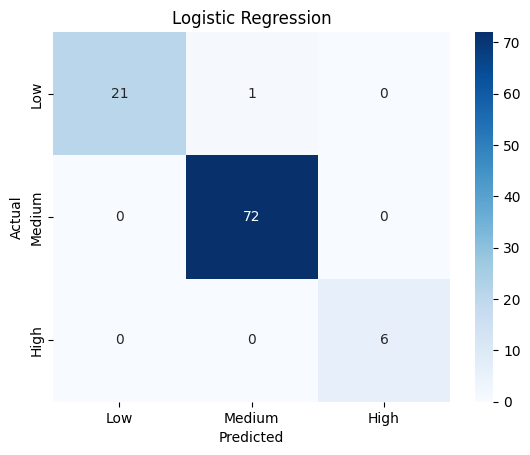

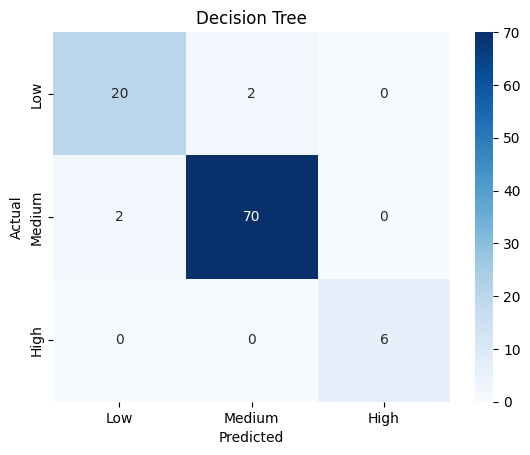

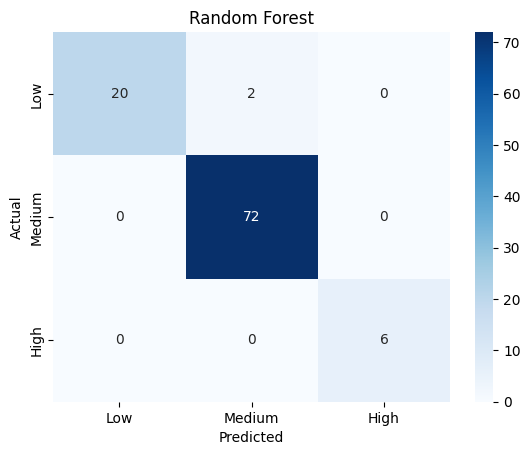

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

plot_confusion(y_test, y_pred_lr, "Logistic Regression")
plot_confusion(y_test, y_pred_dt, "Decision Tree")
plot_confusion(y_test, y_pred_rf, "Random Forest")

## Classification Metrics

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

def classification_metrics(y_true, y_pred):
    return {
        "Precision": precision_score(y_true, y_pred, average="macro"),
        "Recall": recall_score(y_true, y_pred, average="macro"),
        "F1": f1_score(y_true, y_pred, average="macro")
    }

print("Logistic Regression:\n", classification_metrics(y_test, y_pred_lr))
print("\nDecision Tree:\n", classification_metrics(y_test, y_pred_dt))
print("\nRandom Forest:\n", classification_metrics(y_test, y_pred_rf))

Logistic Regression:
 {'Precision': 0.9954337899543378, 'Recall': 0.9848484848484849, 'F1': 0.9899492114407913}

Decision Tree:
 {'Precision': 0.9604377104377105, 'Recall': 0.9604377104377105, 'F1': 0.9604377104377105}

Random Forest:
 {'Precision': 0.990990990990991, 'Recall': 0.9696969696969697, 'F1': 0.9795607740813219}


## Error Analysis

### Medium <--> High confusion

In [ ]:
import pandas as pd

test_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_lr
})

confused_mh = test_df[
    ((test_df["Actual"] == 1) & (test_df["Predicted"] == 2)) |
    ((test_df["Actual"] == 2) & (test_df["Predicted"] == 1))
]

confused_mh.head(10)

,Actual,Predicted


In [ ]:
df_test = df.iloc[X_test.indices[:len(confused_mh)]]
df_test.head()

,message,urgency,clean_message,label


### Low <--> Medium confusion

In [ ]:
confused_lm = test_df[
    ((test_df["Actual"] == 0) & (test_df["Predicted"] == 1)) |
    ((test_df["Actual"] == 1) & (test_df["Predicted"] == 0))
]

confused_lm.head(10)

,Actual,Predicted
125,0,1


In [ ]:
df_test = df.iloc[X_test.indices[:len(confused_lm)]]
df_test.head()

,message,urgency,clean_message,label
48,JUST a reminder about the discussion before en...,medium,reminder discussion end day,1


# Interpretation

## Logistic Regression Coefficients

### Extract feature names

In [ ]:
tfidf_features = tfidf.get_feature_names_out()

extra_feature_names = [
    "message_length",
    "exclamation_count",
    "urgency_keyword_flag",
    "capital_ratio"
]

feature_names = np.concatenate([tfidf_features, extra_feature_names])

### Coefficients for each class

In [ ]:
coef_df = pd.DataFrame(
    log_reg.coef_,
    columns=feature_names,
    index=["Low", "Medium", "High"]
)

coef_df.head()

,approval,approval convenience,approval deadline,approval discussed,approval end,approval meeting,approval noon,approval per,approval planned,approval reference,...,work right,work see,work soon,work submission,work today,work without,message_length,exclamation_count,urgency_keyword_flag,capital_ratio
Low,0.357830,0.134404,0.0,-0.003154,-0.146669,0.0,-0.134174,0.188172,0.0,0.091408,...,-0.015799,-0.127265,-0.148840,-0.016048,-0.000541,-0.028773,1.016545,-0.785736,-2.027867,-0.224016
Medium,-0.339575,-0.132689,0.0,0.009256,0.148253,0.0,0.144546,-0.174206,0.0,-0.082480,...,-0.491661,0.178313,0.185534,0.059128,0.022674,0.162066,-0.318050,0.146979,-0.416945,-0.219505
High,-0.018256,-0.001715,0.0,-0.006101,-0.001584,0.0,-0.010371,-0.013966,0.0,-0.008929,...,0.507460,-0.051048,-0.036694,-0.043081,-0.022134,-0.133293,-0.698494,0.638757,2.444812,0.443521


### Top features per urgency class

In [ ]:
def top_features(class_name, n=10):
    return coef_df.loc[class_name].sort_values(ascending=False).head(n)

print("Top features for LOW urgency\n", top_features("Low"))
print("\nTop features for MEDIUM urgency\n", top_features("Medium"))
print("\nTop features for HIGH urgency\n", top_features("High"))

Top features for LOW urgency
 planned              1.261960
submission           1.189677
message_length       1.016545
without              0.809206
delay                0.809206
without delay        0.809206
reference            0.728668
reminder             0.621115
reminder approval    0.537146
convenience          0.533373
Name: Low, dtype: float64

Top features for MEDIUM urgency
 meeting         1.660775
deadline        1.113562
today           1.111887
end day         0.991159
day             0.991159
end             0.991159
noon            0.895727
discussed       0.882717
please          0.755495
please check    0.755495
Name: Medium, dtype: float64

Top features for HIGH urgency
 right                   2.537463
urgency_keyword_flag    2.444812
exclamation_count       0.638757
meeting right           0.535848
work right              0.507460
document right          0.491634
deadline right          0.487308
capital_ratio           0.443521
discussion right        0.375002
fi

## Random Forest Feature Importance

In [ ]:
rf_importances = rf.feature_importances_

rf_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_importances
}).sort_values(by="importance", ascending=False)

rf_imp_df.head(15)

,feature,importance
227,right,0.105573
307,capital_ratio,0.086717
179,reminder,0.046205
175,please,0.036167
152,meeting,0.033613
304,message_length,0.033478
306,urgency_keyword_flag,0.032458
305,exclamation_count,0.030808
48,check,0.030563
176,please check,0.028128


### Plotting top features

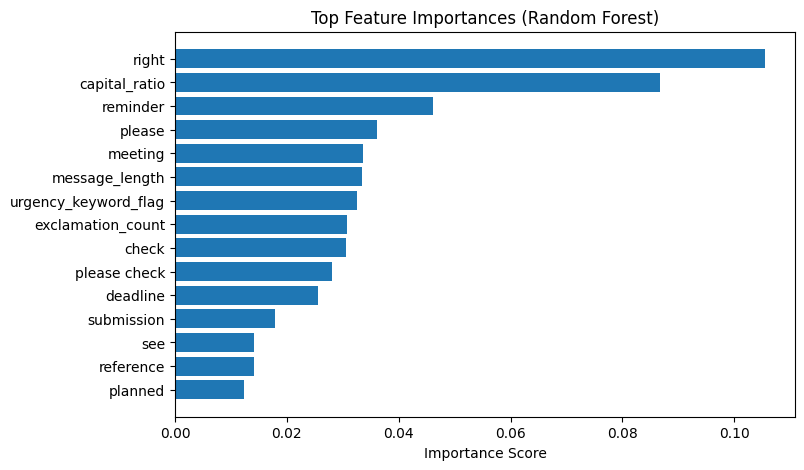

In [ ]:
import matplotlib.pyplot as plt

top_rf = rf_imp_df.head(15)

plt.figure(figsize=(8, 5))
plt.barh(top_rf["feature"], top_rf["importance"])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

## Explanation using examples from test set

In [ ]:
sample_indices = np.random.choice(X_test.shape[0], 5, replace=False)

sample_probs = log_reg.predict_proba(X_test[sample_indices])
sample_preds = log_reg.predict(X_test[sample_indices])

sample_probs, sample_preds

(array([[0.02879231, 0.88789321, 0.08331448],
        [0.58997048, 0.40156477, 0.00846475],
        [0.00289864, 0.9895959 , 0.00750546],
        [0.0525258 , 0.85186077, 0.09561343],
        [0.52224883, 0.46709159, 0.01065957]]),
 array([1, 0, 1, 1, 0]))

In [ ]:
reverse_mapping = {0: "Low", 1: "Medium", 2: "High"}

example_df = pd.DataFrame({
    "message": df["message"].loc[y_test.index].iloc[sample_indices].values,
    "actual_label": [reverse_mapping[i] for i in y_test.iloc[sample_indices]],
    "predicted_label": [reverse_mapping[i] for i in sample_preds],
    "confidence_low": sample_probs[:, 0],
    "confidence_medium": sample_probs[:, 1],
    "confidence_high": sample_probs[:, 2]
})

example_df

,message,actual_label,predicted_label,confidence_low,confidence_medium,confidence_high
0,Just a reminder about today’s work before subm...,Medium,Medium,0.028792,0.887893,0.083314
1,Just a reminder about the approval as planned.,Low,Low,0.589970,0.401565,0.008465
2,Please check this issue before deadline.,Medium,Medium,0.002899,0.989596,0.007505
3,Just a reminder about the document today itself.,Medium,Medium,0.052526,0.851861,0.095613
4,Just a reminder about the file before submission.,Low,Low,0.522249,0.467092,0.010660


# API deployment

## Install dependencies (for Colab)

In [ ]:
!pip install fastapi uvicorn pyngrok nest-asyncio

## Load artifacts and runtime preprocessing

In [ ]:
import joblib
import re
from fastapi import FastAPI
from pydantic import BaseModel

log_reg = joblib.load("logistic_regression_model.joblib")
tfidf = joblib.load("tfidf_vectorizer.joblib")
urgency_mapping = joblib.load("urgency_mapping.joblib")
reverse_mapping = {v: k for k, v in urgency_mapping.items()}

# same cleaning function as Day 2
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    return text


## API schema

In [ ]:
class MessageInput(BaseModel):
    message: str

## FastAPI app

In [ ]:
import numpy as np

urgency_keywords = [
    "urgent", "asap", "immediately", "now", "today", "tonight"
]

def extra_features(text):
    length = len(text.split())
    exclamations = text.count("!")
    keyword_flag = int(any(word in text.lower() for word in urgency_keywords))
    caps_ratio = sum(1 for c in text if c.isupper()) / max(len(text), 1)
    return np.array([[length, exclamations, keyword_flag, caps_ratio]])


In [ ]:
app = FastAPI(title="Smart Message Prioritization API")

@app.post("/predict-urgency")
def predict_urgency(input: MessageInput):
    cleaned = clean_text(input.message)

    # TF-IDF features
    X_tfidf = tfidf.transform([cleaned])

    # Extra features
    X_extra = extra_features(input.message)

    # Combine exactly like training
    from scipy.sparse import hstack
    X_final = hstack([X_tfidf, X_extra])

    probs = log_reg.predict_proba(X_final)[0]
    pred = probs.argmax()

    return {
        "message": input.message,
        "predicted_urgency": reverse_mapping[pred],
        "confidence": {
            "Low": float(probs[0]),
            "Medium": float(probs[1]),
            "High": float(probs[2])
        }
    }


## Prototype deployment

In [ ]:
import uvicorn
from uvicorn import Config, Server

config = Config(
    app=app,
    host="0.0.0.0",
    port=8000,
    log_level="info"
)

server = Server(config)
await server.serve()


INFO:     Started server process [511]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [511]


In [ ]:
test_input = MessageInput(message="Review task now")
predict_urgency(test_input)

{'message': 'Review task now',
 'predicted_urgency': 'high',
 'confidence': {'Low': 4.3171399107920714e-05,
  'Medium': 0.4074755814996225,
  'High': 0.5924812471012696}}

In [ ]:
test_input = MessageInput(message="Please share the updated slides by end of day for today's client review.")
predict_urgency(test_input)

{'message': "Please share the updated slides by end of day for today's client review.",
 'predicted_urgency': 'low',
 'confidence': {'Low': 0.5946607636330806,
  'Medium': 0.40373870006420165,
  'High': 0.0016005363027175245}}